Part 1 - Metropolis-Hastings, Truncated Poisson

In [28]:
import numpy as np
import math
from scipy.stats import chisquare

In [29]:
A = 8
m = 10

In [30]:
def g(i):
    return A**i / math.factorial(i)

def proposal_probability(x, y):

    if x == 0:

        if y == 1:
            return 1.0
        return 0.0

    if x == m:

        if y == m - 1:
            return 1.0
        return 0.0

    if y == x - 1:
        return 0.5

    if y == x + 1:
        return 0.5

    return 0.0

def metropolis_poisson(
        n_samples=100000,
        burnin=50000):

    x = 0

    samples = []

    for t in range(n_samples + burnin):

        if x == 0:
            y = 1

        elif x == m:
            y = m - 1

        else:
            y = x + np.random.choice([-1,1])

        hxy = proposal_probability(x,y)
        hyx = proposal_probability(y,x)

        alpha = min(
            1.0,
            g(y)*hyx/(g(x)*hxy)
        )

        if np.random.rand() < alpha:
            x = y

        if t >= burnin:
            samples.append(x)

    return np.array(samples)

In [31]:
weights = np.array(
    [g(i) for i in range(m + 1)]
)

prob = weights / weights.sum()

In [32]:
samples = metropolis_poisson()

observed = np.bincount(
    samples,
    minlength=m+1
)

expected = len(samples) * prob

chi2, pvalue = chisquare(
    observed,
    expected
)

print("Chi-square =", chi2)
print("p-value =", pvalue)

Chi-square = 65.30828802645374
p-value = 3.5384796938176576e-10


Part 2.a - Direct Metropolis-Hastings

In [33]:
A1 = 4
A2 = 4
m = 10

def g2(i,j):

    if i < 0:
        return 0

    if j < 0:
        return 0

    if i+j > m:
        return 0

    return (
        A1**i/math.factorial(i)
        *
        A2**j/math.factorial(j)
    )

In [34]:
def neighbours(state):

    i,j = state

    candidates = [
        (i+1,j),
        (i-1,j),
        (i,j+1),
        (i,j-1)
    ]

    legal = []

    for a,b in candidates:

        if (
            a >= 0 and
            b >= 0 and
            a+b <= m
        ):
            legal.append((a,b))

    return legal

In [35]:
def h(state,new_state):

    neigh = neighbours(state)

    if new_state in neigh:
        return 1/len(neigh)

    return 0

In [36]:
def mh_2d(
        n_samples=100000,
        burnin=50000):

    x = (0,0)

    samples = []

    for t in range(
            n_samples + burnin):

        neigh = neighbours(x)

        y = neigh[
            np.random.randint(
                len(neigh)
            )
        ]

        alpha = min(
            1.0,
            g2(*y)*h(y,x)
            /
            (
                g2(*x)*h(x,y)
            )
        )

        if np.random.rand() < alpha:
            x = y

        if t >= burnin:
            samples.append(x)

    return samples

In [37]:
states = []
weights = []

for i in range(m+1):

    for j in range(m+1-i):

        states.append((i,j))

        weights.append(
            g2(i,j)
        )

weights = np.array(weights)

prob = weights/weights.sum()

In [38]:
from collections import Counter

samples = mh_2d()

count = Counter(samples)

observed = np.array(
    [count[s] for s in states]
)

expected = len(samples)*prob

obs_combined = []
exp_combined = []

temp_obs = 0
temp_exp = 0

for o,e in zip(
        observed,
        expected):

    temp_obs += o
    temp_exp += e

    if temp_exp >= 5:

        obs_combined.append(
            temp_obs
        )

        exp_combined.append(
            temp_exp
        )

        temp_obs = 0
        temp_exp = 0

if temp_exp > 0:

    obs_combined[-1] += temp_obs
    exp_combined[-1] += temp_exp

chi2,pvalue = chisquare(
    obs_combined,
    exp_combined
)

print(pvalue)

2.1977565013240838e-05


Part 2.b - Coordinatewise Metropolis-Hastings

In [24]:
def coordinate_mh(
        n_samples=100000,
        burnin=5000):

    i = 0
    j = 0

    samples = []

    for t in range(n_samples + burnin):

        # update i

        move = np.random.choice([-1,1])

        ip = i + move

        if (
            ip >= 0 and
            ip + j <= m
        ):

            alpha = min(
                1.0,
                g2(ip,j) / g2(i,j)
            )

            if np.random.rand() < alpha:
                i = ip

        # update j

        move = np.random.choice([-1,1])

        jp = j + move

        if (
            jp >= 0 and
            i + jp <= m
        ):

            alpha = min(
                1.0,
                g2(i,jp) / g2(i,j)
            )

            if np.random.rand() < alpha:
                j = jp

        if t >= burnin:
            samples.append((i,j))

    return samples

In [25]:
samples = coordinate_mh()

count = Counter(samples)

observed = np.array(
    [count[s] for s in states]
)

expected = len(samples) * prob

chi2, pvalue = chisquare(
    observed,
    expected
)

print(pvalue)

0.0004718328960331369


Part 2.c - Gibbs Sampling

In [26]:
def sample_truncated_poisson(A, max_value):

    w = np.array([
        A**k / math.factorial(k)
        for k in range(max_value + 1)
    ])

    w /= w.sum()

    return np.random.choice(
        np.arange(max_value + 1),
        p=w
    )

def gibbs_sampler(
        n_samples=100000,
        burnin=5000):

    i = 0
    j = 0

    samples = []

    for t in range(n_samples + burnin):

        i = sample_truncated_poisson(
            A1,
            m - j
        )

        j = sample_truncated_poisson(
            A2,
            m - i
        )

        if t >= burnin:
            samples.append((i,j))

    return samples

In [27]:
samples = gibbs_sampler()

count = Counter(samples)

observed = np.array(
    [count[s] for s in states]
)

expected = len(samples) * prob

chi2, pvalue = chisquare(
    observed,
    expected
)

print(pvalue)

0.3945262707919485


Part 3.a - Prior Sample

In [ ]:
import numpy as np

rho = 0.5

Sigma = np.array([
    [1, rho],
    [rho, 1]
])

xi, gamma = np.random.multivariate_normal(
    mean=[0, 0],
    cov=Sigma
)

theta = np.exp(xi)
psi = np.exp(gamma)

print("theta =", theta)
print("psi =", psi)

theta = 1.5126255818300547
psi = 3.1284420851934995


Part 3.b - Simulate Data

In [ ]:
n = 10

x = np.random.normal(
    loc=theta,
    scale=np.sqrt(psi),
    size=n
)

In [41]:
xbar = np.mean(x)

s2 = np.var(
    x,
    ddof=1
)

print("mean =",xbar)
print("variance =",s2)

mean = 0.9711852138617868
variance = 5.819577602443456


Part 3.c - Derive Posterior

In [ ]:
rho = 0.5

def log_posterior(theta, psi, data):

    if theta <= 0:
        return -np.inf

    if psi <= 0:
        return -np.inf

    n = len(data)

    sse = np.sum(
        (data-theta)**2
    )

    loglik = (
        -n/2*np.log(psi)
        -sse/(2*psi)
    )

    logprior = (
        -np.log(theta)
        -np.log(psi)
        -
        (
            np.log(theta)**2
            -
            2*rho*np.log(theta)*np.log(psi)
            +
            np.log(psi)**2
        )
        /
        (
            2*(1-rho**2)
        )
    )

    return loglik + logprior

Part 3.d - Metropolis-Hastings

In [43]:
def mh_sampler(
        data,
        n_iter=100000,
        burnin=20000):

    xi = 0.0
    gamma = 0.0

    samples = []

    proposal_sd = 0.15

    current_lp = log_posterior(
        np.exp(xi),
        np.exp(gamma),
        data
    )

    for t in range(n_iter):

        xi_prop = (
            xi
            +
            np.random.normal(
                0,
                proposal_sd
            )
        )

        gamma_prop = (
            gamma
            +
            np.random.normal(
                0,
                proposal_sd
            )
        )

        proposed_lp = log_posterior(
            np.exp(xi_prop),
            np.exp(gamma_prop),
            data
        )

        log_alpha = (
            proposed_lp
            -
            current_lp
        )

        if np.log(np.random.rand()) < log_alpha:

            xi = xi_prop
            gamma = gamma_prop

            current_lp = proposed_lp

        if t >= burnin:

            samples.append(
                (
                    np.exp(xi),
                    np.exp(gamma)
                )
            )

    return np.array(samples)

In [44]:
posterior = mh_sampler(x)

theta_samples = posterior[:,0]
psi_samples   = posterior[:,1]

In [45]:
print(
    np.mean(theta_samples)
)

print(
    np.mean(psi_samples)
)

0.8597443895327735
3.862584863571592


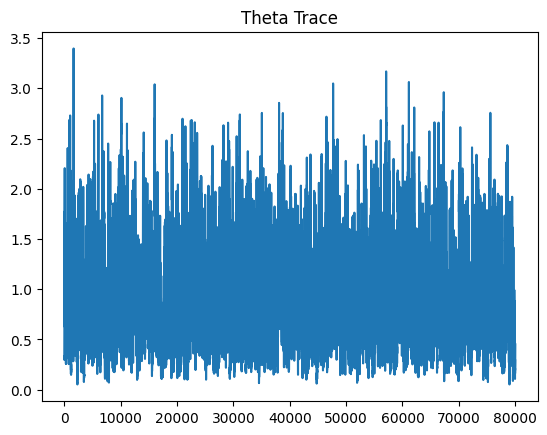

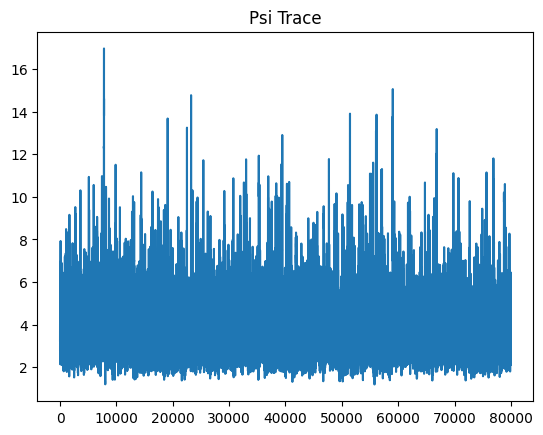

In [46]:
import matplotlib.pyplot as plt

plt.plot(theta_samples)
plt.title("Theta Trace")
plt.show()

plt.plot(psi_samples)
plt.title("Psi Trace")
plt.show()

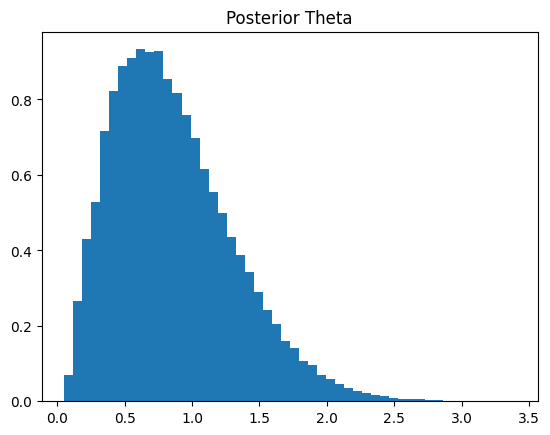

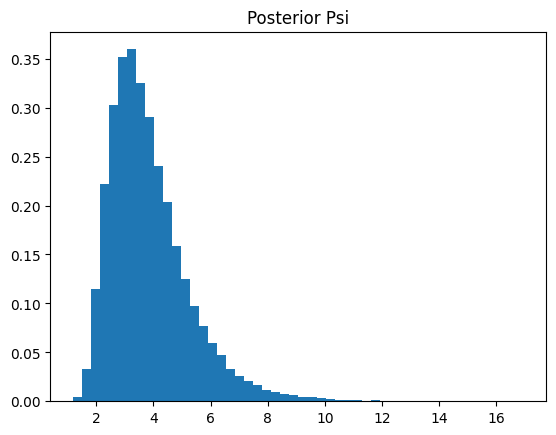

In [47]:
plt.hist(
    theta_samples,
    bins=50,
    density=True
)
plt.title("Posterior Theta")
plt.show()

plt.hist(
    psi_samples,
    bins=50,
    density=True
)
plt.title("Posterior Psi")
plt.show()

Part 3.e - n = 100 & n = 1000

In [48]:
x100 = np.random.normal(
    theta,
    np.sqrt(psi),
    100
)

x1000 = np.random.normal(
    theta,
    np.sqrt(psi),
    1000
)

In [49]:
post10 = mh_sampler(x)

post100 = mh_sampler(x100)

post1000 = mh_sampler(x1000)

In [50]:
for name, post in [
    ("n=10",post10),
    ("n=100",post100),
    ("n=1000",post1000)
]:

    print(name)

    print(
        np.std(post[:,0])
    )

    print(
        np.std(post[:,1])
    )

n=10
0.44791880645062926
1.4613622491448446
n=100
0.1670811423548889
0.4001549868987039
n=1000
0.0570614970118784
0.14150988675354664
